# Exploratory Data Analysis (EDA)


## 1. Load the Dataset

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("data/Airline_Delay_Cause.csv")

# Show the first 5 rows
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


## 2. Data Structure, Info and Duplicates

In [22]:
# Number of rows and columns
print("Shape:", df.shape)

Shape: (171666, 21)


In [23]:
# Column names, data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 171666 entries, 0 to 171665
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 171666 non-null  int64  
 1   month                171666 non-null  int64  
 2   carrier              171666 non-null  str    
 3   carrier_name         171666 non-null  str    
 4   airport              171666 non-null  str    
 5   airport_name         171666 non-null  str    
 6   arr_flights          171426 non-null  float64
 7   arr_del15            171223 non-null  float64
 8   carrier_ct           171426 non-null  float64
 9   weather_ct           171426 non-null  float64
 10  nas_ct               171426 non-null  float64
 11  security_ct          171426 non-null  float64
 12  late_aircraft_ct     171426 non-null  float64
 13  arr_cancelled        171426 non-null  float64
 14  arr_diverted         171426 non-null  float64
 15  arr_delay            171426 

In [24]:
# Summary statistics for numeric columns
df.describe()

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,171666.000000,171666.000000,171426.000000,171223.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.00000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000
mean,2018.551361,6.493633,362.528467,66.434387,20.796615,2.250347,19.381147,0.157096,23.770554,7.530497,0.863387,4239.48733,1437.185124,222.563497,920.651704,7.382725,1651.700063
std,2.890006,3.440908,992.894662,179.540694,50.315176,7.314252,61.675244,0.717405,72.393477,43.654880,3.772853,12618.56605,4215.677812,821.086511,3423.509335,41.779985,5221.878385
min,2013.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,4.000000,50.000000,6.000000,2.160000,0.000000,1.000000,0.000000,1.230000,0.000000,0.000000,335.00000,110.000000,0.000000,34.000000,0.000000,65.000000
50%,2019.000000,7.000000,100.000000,17.000000,6.400000,0.400000,3.910000,0.000000,5.000000,1.000000,0.000000,1018.00000,375.000000,18.000000,146.000000,0.000000,320.000000
75%,2021.000000,9.000000,250.000000,47.000000,17.260000,1.860000,11.710000,0.000000,15.260000,4.000000,1.000000,2884.00000,1109.000000,146.000000,477.000000,0.000000,1070.000000
max,2023.000000,12.000000,21977.000000,4176.000000,1293.910000,266.420000,1884.420000,58.690000,2069.070000,4951.000000,197.000000,438783.00000,196944.000000,31960.000000,112018.000000,3760.000000,227959.000000


In [25]:
# Count fully duplicated rows
print("Duplicate rows:", df.duplicated().sum())

# Count duplicate year-month-carrier-airport combinations
key = ["year", "month", "carrier", "airport"]
print("Duplicate keys:", df.duplicated(subset=key).sum())

Duplicate rows: 0
Duplicate keys: 0


## 3. Variable Types

In [26]:
# Split columns into logical types for later encoding/scaling decisions
identifier_cols = ["carrier", "carrier_name", "airport", "airport_name"]
temporal_cols = ["year", "month"]
numeric_cols = [c for c in df.columns if c not in identifier_cols + temporal_cols]

print("Categorical / identifier columns:", identifier_cols)
print("Temporal columns:", temporal_cols)
print("Numeric columns:", numeric_cols)


Categorical / identifier columns: ['carrier', 'carrier_name', 'airport', 'airport_name']
Temporal columns: ['year', 'month']
Numeric columns: ['arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']


**Observation:** `carrier`/`airport` are nominal categorical codes (`carrier_name`/`airport_name` are just their human-readable labels and therefore redundant). `year` and `month` are temporal features. Everything else is a numeric count or duration describing what happened to arriving flights in that carrier-airport-month.

## 4. Missing Values

In [27]:
# Count and percentage of missing values in each column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_table

,Missing Count,Missing %
year,0,0.00
month,0,0.00
carrier,0,0.00
carrier_name,0,0.00
airport,0,0.00
airport_name,0,0.00
arr_flights,240,0.14
arr_del15,443,0.26
carrier_ct,240,0.14
weather_ct,240,0.14


## 5. Categorical Variable Distribution

In [28]:
print("Number of unique carriers:", df["carrier"].nunique())
print("Number of unique airports:", df["airport"].nunique())

Number of unique carriers: 21
Number of unique airports: 395


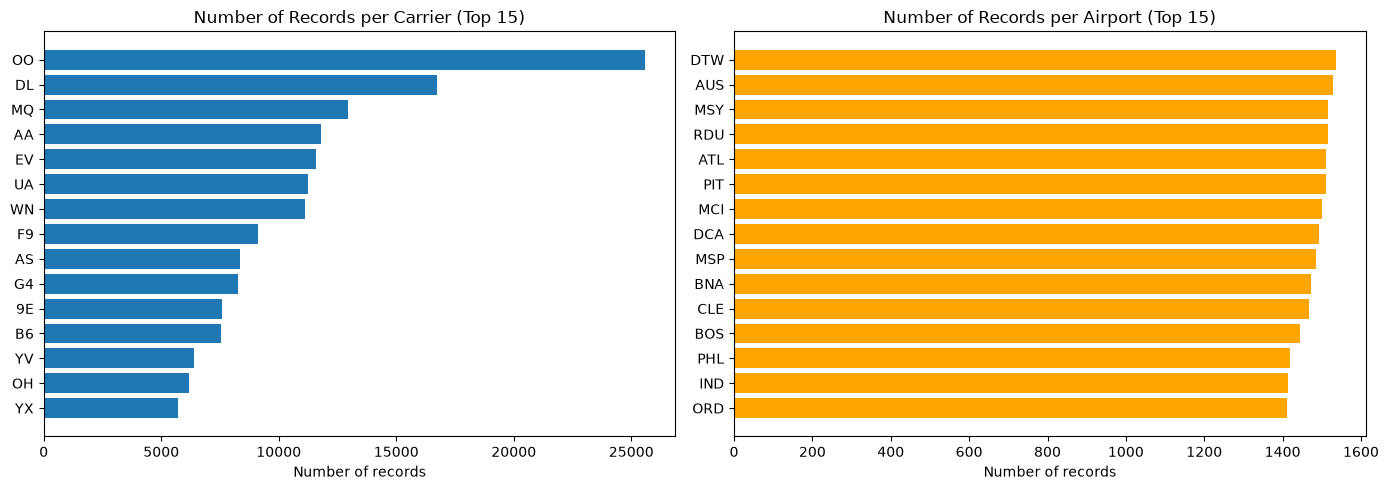

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Records per carrier (top 15)
carrier_counts = df["carrier"].value_counts().head(15)
axes[0].barh(carrier_counts.index[::-1], carrier_counts.values[::-1])
axes[0].set_title("Number of Records per Carrier (Top 15)")
axes[0].set_xlabel("Number of records")

# Records per airport (top 15 busiest)
airport_counts = df["airport"].value_counts().head(15)
axes[1].barh(airport_counts.index[::-1], airport_counts.values[::-1], color="orange")
axes[1].set_title("Number of Records per Airport (Top 15)")
axes[1].set_xlabel("Number of records")

plt.tight_layout()
plt.show()


**Observation:** `carrier` has only 21 categories and is reasonably balanced -- suitable for one-hot encoding. `airport` has 395 categories with a long tail of small airports; one-hot encoding would create hundreds of sparse columns, so a lower-cardinality encoding (frequency encoding) is used instead in Stage 4.

## 6. Distribution of arr_flights and arr_del15

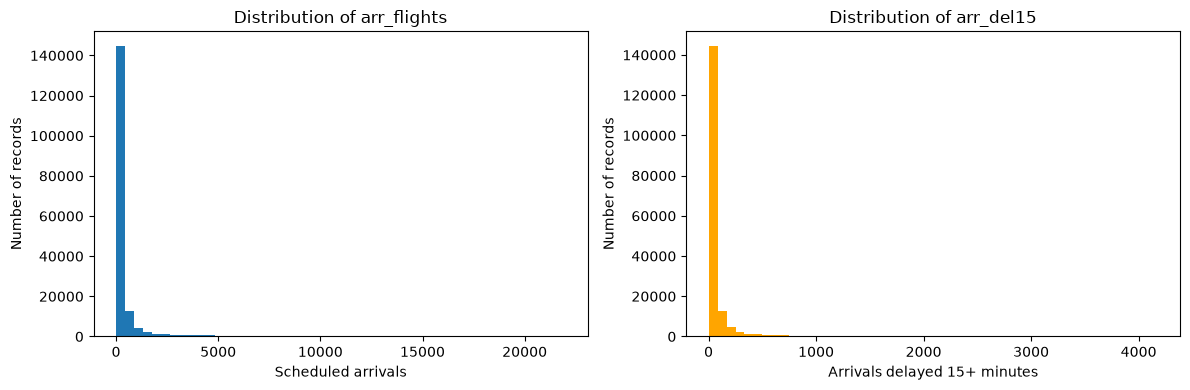

In [30]:
# Histograms of the two key columns, side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["arr_flights"].dropna(), bins=50)
axes[0].set_title("Distribution of arr_flights")
axes[0].set_xlabel("Scheduled arrivals")
axes[0].set_ylabel("Number of records")

axes[1].hist(df["arr_del15"].dropna(), bins=50, color="orange")
axes[1].set_title("Distribution of arr_del15")
axes[1].set_xlabel("Arrivals delayed 15+ minutes")
axes[1].set_ylabel("Number of records")

plt.tight_layout()
plt.show()

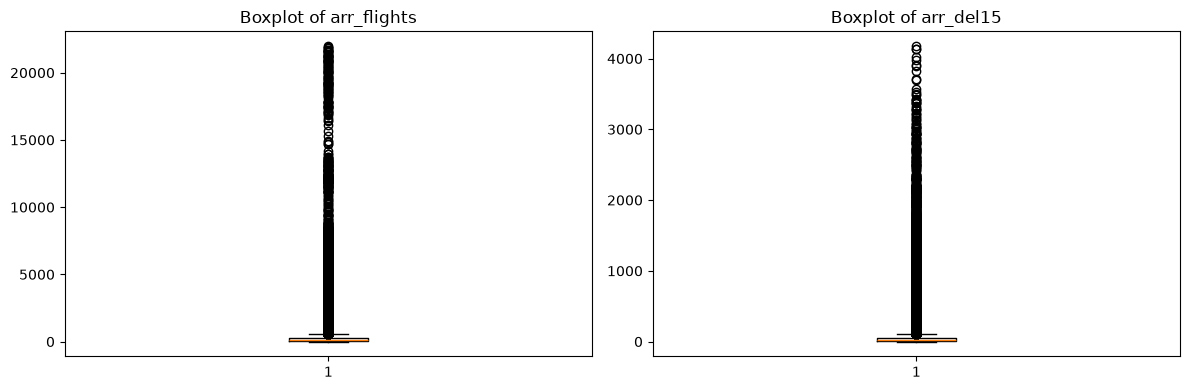

In [31]:
# Boxplots show the outliers (very large hub airports)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df["arr_flights"].dropna())
axes[0].set_title("Boxplot of arr_flights")

axes[1].boxplot(df["arr_del15"].dropna())
axes[1].set_title("Boxplot of arr_del15")

plt.tight_layout()
plt.show()

**Observation:** Both columns are strongly right-skewed. Most carrier-airport-months are small, while a few large hubs have very high values. This is why the target uses the delay **rate** (`arr_del15 / arr_flights`) instead of the raw count.

## 7. Outlier Investigation

In [32]:
def iqr_outlier_summary(series, name):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((series < lower) | (series > upper)).sum()
    pct = n_outliers / series.notna().sum() * 100
    print(f"{name}: IQR bounds = [{lower:.1f}, {upper:.1f}]  "
          f"-> {n_outliers} outliers ({pct:.2f}% of non-missing records)")
    return lower, upper

lo_f, hi_f = iqr_outlier_summary(df["arr_flights"].dropna(), "arr_flights")
lo_d, hi_d = iqr_outlier_summary(df["arr_del15"].dropna(), "arr_del15")


arr_flights: IQR bounds = [-250.0, 550.0]  -> 21642 outliers (12.62% of non-missing records)
arr_del15: IQR bounds = [-55.5, 108.5]  -> 21148 outliers (12.35% of non-missing records)


In [33]:
# Which airports do the high-end arr_flights outliers belong to?
outlier_rows = df[df["arr_flights"] > hi_f]
print("Top airports among arr_flights outliers:")
print(outlier_rows["airport_name"].value_counts().head(10))


Top airports among arr_flights outliers:
airport_name
Los Angeles, CA: Los Angeles International               909
Chicago, IL: Chicago O'Hare International                842
Orlando, FL: Orlando International                       789
New York, NY: LaGuardia                                  735
Denver, CO: Denver International                         714
San Francisco, CA: San Francisco International           682
Atlanta, GA: Hartsfield-Jackson Atlanta International    671
Seattle, WA: Seattle/Tacoma International                652
Boston, MA: Logan International                          622
Phoenix, AZ: Phoenix Sky Harbor International            613
Name: count, dtype: int64


**Observation:** The IQR method flags a meaningful share of records as statistical outliers, but checking *which* airports they belong to shows they are dominated by well-known major hubs (e.g. large international airports) -- these are genuine large-scale operations, not data-entry errors. This informs the Stage 4 decision to **cap (winsorize) rather than delete** these values, so the information from large hubs is kept but its influence on distance/scale-sensitive models is reduced.

## 8. Relationship Between Variables

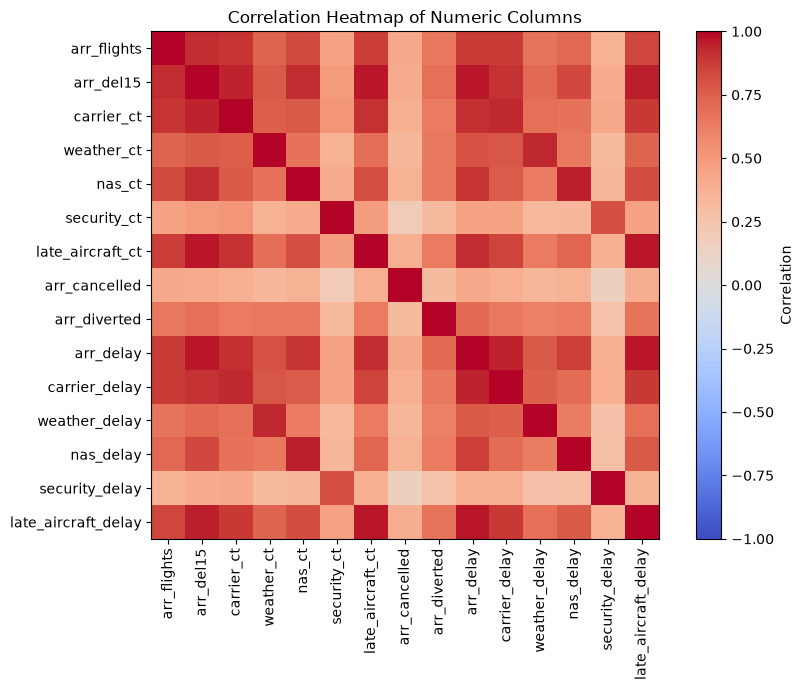

In [34]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Heatmap of Numeric Columns")
plt.tight_layout()
plt.show()


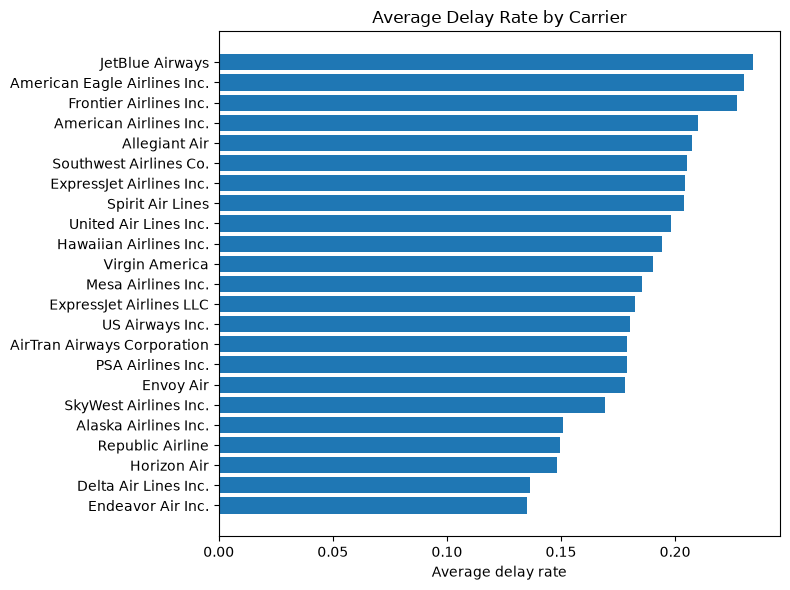

In [35]:
# Delay rate = share of arrivals delayed 15+ minutes (built here only to explore relationships/imbalance;
# the same formula is used to build the actual target column in Stage 4)
eda = df.dropna(subset=["arr_flights", "arr_del15"]).copy()
eda = eda[eda["arr_flights"] > 0]
eda["delay_rate"] = eda["arr_del15"] / eda["arr_flights"]

# Average delay rate by carrier
carrier_rate = eda.groupby("carrier_name")["delay_rate"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(carrier_rate.index[::-1], carrier_rate.values[::-1])
ax.set_title("Average Delay Rate by Carrier")
ax.set_xlabel("Average delay rate")
plt.tight_layout()
plt.show()

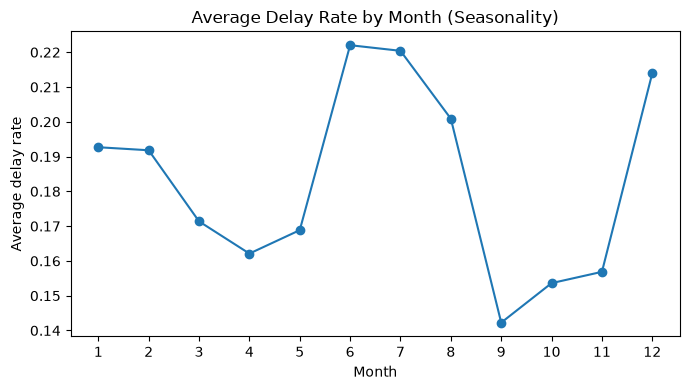

In [36]:
# Seasonality: average delay rate by month
month_rate = eda.groupby("month")["delay_rate"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(month_rate.index, month_rate.values, marker="o")
ax.set_title("Average Delay Rate by Month (Seasonality)")
ax.set_xlabel("Month")
ax.set_ylabel("Average delay rate")
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()


## 9. Class Imbalance

In [37]:
# Preview how the planned target (delay_risk_category) would be distributed.
# The exact same thresholds and logic are used to build the real target column in Stage 4.
def get_risk_category(rate):
    if rate < 0.15:
        return "Low Risk"
    elif rate <= 0.25:
        return "Moderate Risk"
    else:
        return "High Risk"

eda["delay_risk_category"] = eda["delay_rate"].apply(get_risk_category)

counts = eda["delay_risk_category"].value_counts()
pct = eda["delay_risk_category"].value_counts(normalize=True).round(4) * 100
print(counts)
print()
print(pct)


delay_risk_category
Low Risk         70452
Moderate Risk    62906
High Risk        37865
Name: count, dtype: int64

delay_risk_category
Low Risk         41.15
Moderate Risk    36.74
High Risk        22.11
Name: proportion, dtype: float64


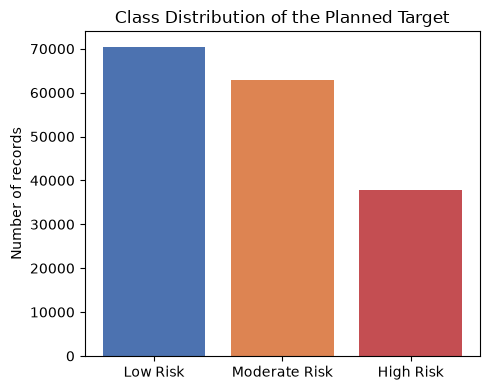

In [38]:
fig, ax = plt.subplots(figsize=(5, 4))
order = ["Low Risk", "Moderate Risk", "High Risk"]
ax.bar(order, counts.reindex(order).values, color=["#4C72B0", "#DD8452", "#C44E52"])
ax.set_title("Class Distribution of the Planned Target")
ax.set_ylabel("Number of records")
plt.tight_layout()
plt.show()


## 10. Data Leakage Check
If the five delay-cause counts add up to `arr_del15`, they are just the target split by cause and must be excluded from the model inputs.

In [39]:
# The five delay-cause count columns
cause_cols = ["carrier_ct", "weather_ct", "nas_ct", "security_ct", "late_aircraft_ct"]

# Keep only rows where all needed values are present
check = df.dropna(subset=cause_cols + ["arr_del15"]).copy()

# Add up the five causes for each row
check["cause_sum"] = check[cause_cols].sum(axis=1)

# How different is the sum from arr_del15?
diff = (check["cause_sum"] - check["arr_del15"]).abs()
print("Mean absolute difference:", round(diff.mean(), 4))
print("Max absolute difference:", round(diff.max(), 4))

Mean absolute difference: 0.0023
Max absolute difference: 1.0


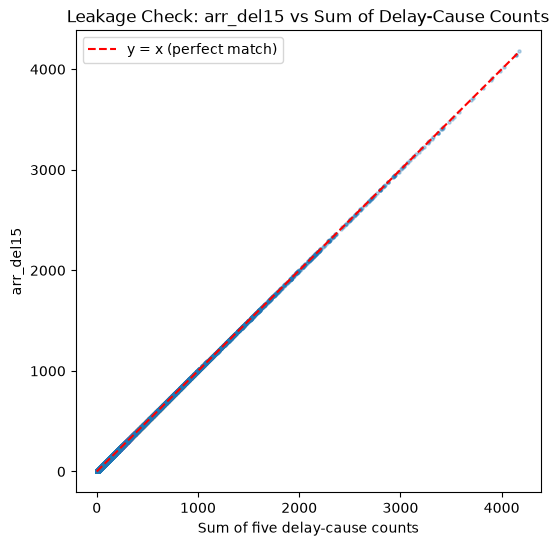

In [40]:
# Scatter plot: sum of causes vs arr_del15
plt.figure(figsize=(6, 6))
plt.scatter(check["cause_sum"], check["arr_del15"], s=5, alpha=0.3)

# Red dashed y = x line (perfect match)
max_val = check["arr_del15"].max()
plt.plot([0, max_val], [0, max_val], "r--", label="y = x (perfect match)")

plt.title("Leakage Check: arr_del15 vs Sum of Delay-Cause Counts")
plt.xlabel("Sum of five delay-cause counts")
plt.ylabel("arr_del15")
plt.legend()
plt.show()

**Conclusion:** The points lie on the y = x line, so the five `_ct` columns simply add up to `arr_del15` (tiny differences come from rounding). They leak the target and are **excluded** from the model inputs, along with `arr_delay`, the five `_delay` columns, `arr_cancelled` and `arr_diverted`.